# Community Detection on Zachary's Karate Club
## Implementing & Comparing All Major Algorithms

This notebook implements **6 community detection algorithms** on the classic Zachary's Karate Club dataset:

| # | Algorithm | Type | Key Idea |
|---|-----------|------|----------|
| 1 | **Girvan-Newman** | Divisive | Remove high-betweenness edges |
| 2 | **Greedy Modularity** | Agglomerative | Merge to maximize Q |
| 3 | **Louvain** | Hierarchical | Phase 1 + Phase 2 iteratively |
| 4 | **Label Propagation** | Propagation | Nodes adopt majority neighbor label |
| 5 | **K-Clique Percolation** | Clique-based | Overlapping clique communities |
| 6 | **Spectral Clustering** | Algebraic | Laplacian eigenvectors |

---


## 0. Imports & Setup

In [1]:
import networkx as nx
import networkx.algorithms.community as nx_comm
import community as community_louvain          # python-louvain (Blondel et al.)
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import numpy as np
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# ── Consistent colour palette for up to 8 communities
PALETTE = ['#e6194b','#3cb44b','#4363d8','#f58231',
           '#911eb4','#42d4f4','#f032e6','#bfef45']

def color_map(partition_dict, G):
    """Return a list of colours in node order for nx.draw."""
    return [PALETTE[partition_dict[n] % len(PALETTE)] for n in G.nodes()]

def legend_patches(partition_dict):
    communities = sorted(set(partition_dict.values()))
    return [mpatches.Patch(color=PALETTE[c % len(PALETTE)],
                           label=f'Community {c}') for c in communities]

print("✅ All imports successful")
print(f"   NetworkX  : {nx.__version__}")
print(f"   Algorithms available: Girvan-Newman, Greedy Modularity,")
print(f"   Louvain, Label Propagation, K-Clique, Spectral")


✅ All imports successful
   NetworkX  : 3.6.1
   Algorithms available: Girvan-Newman, Greedy Modularity,
   Louvain, Label Propagation, K-Clique, Spectral


## 1. Load the Dataset

**Zachary's Karate Club** — a classic benchmark network:
- **34 nodes** (club members)
- **78 edges** (interactions outside the club)
- **Ground truth:** 2 communities (split caused by a conflict between instructor and president)


In [2]:
# Load built-in karate club graph
G = nx.karate_club_graph()

# Ground truth: 'Mr. Hi' = instructor's side, 'Officer' = president's side
ground_truth = {n: 0 if G.nodes[n]['club'] == 'Mr. Hi' else 1
                for n in G.nodes()}

print("=" * 45)
print("       KARATE CLUB DATASET SUMMARY")
print("=" * 45)
print(f"  Nodes          : {G.number_of_nodes()}")
print(f"  Edges          : {G.number_of_edges()}")
print(f"  Avg degree     : {2*G.number_of_edges()/G.number_of_nodes():.2f}")
print(f"  Density        : {nx.density(G):.4f}")
print(f"  Is connected   : {nx.is_connected(G)}")
print(f"  Communities    : 2 (ground truth)")
print("=" * 45)
print()
print("Ground truth split:")
mr_hi    = [n for n, c in ground_truth.items() if c == 0]
officer  = [n for n, c in ground_truth.items() if c == 1]
print(f"  Mr. Hi's side    ({len(mr_hi):2d} members): {sorted(mr_hi)}")
print(f"  Officer's side   ({len(officer):2d} members): {sorted(officer)}")


       KARATE CLUB DATASET SUMMARY
  Nodes          : 34
  Edges          : 78
  Avg degree     : 4.59
  Density        : 0.1390
  Is connected   : True
  Communities    : 2 (ground truth)

Ground truth split:
  Mr. Hi's side    (17 members): [0, 1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 16, 17, 19, 21]
  Officer's side   (17 members): [9, 14, 15, 18, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33]


### Visualise Ground Truth

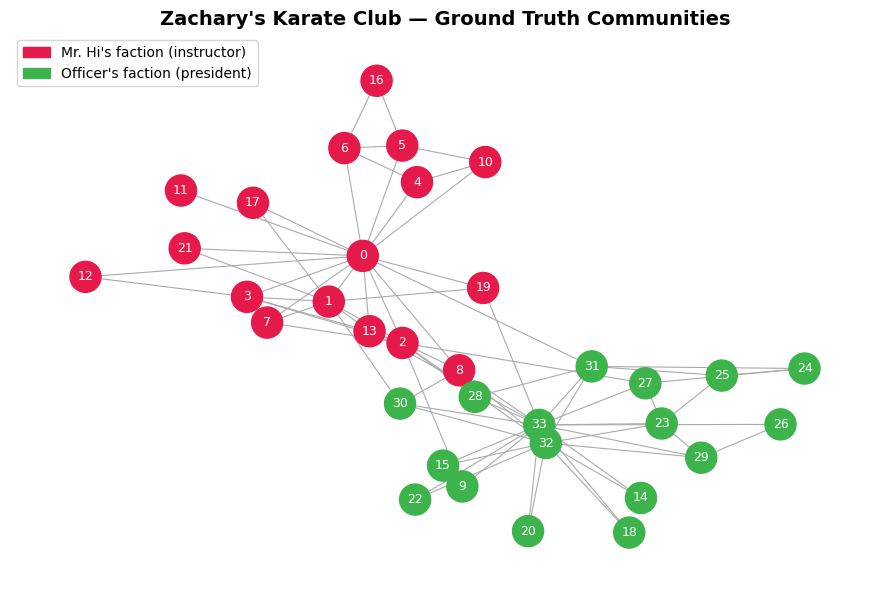

Node 0 = Instructor (Mr. Hi) | Node 33 = President (Officer)


In [3]:
pos = nx.spring_layout(G, seed=42)   # fixed layout used throughout

fig, ax = plt.subplots(figsize=(9, 6))
nx.draw_networkx(G, pos=pos,
                 node_color=[PALETTE[ground_truth[n]] for n in G.nodes()],
                 node_size=500, font_size=9, font_color='white',
                 edge_color='#aaaaaa', width=0.8, ax=ax)
ax.legend(handles=[
    mpatches.Patch(color=PALETTE[0], label="Mr. Hi's faction (instructor)"),
    mpatches.Patch(color=PALETTE[1], label="Officer's faction (president)")
], fontsize=10, loc='upper left')
ax.set_title("Zachary's Karate Club — Ground Truth Communities", fontsize=14, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig('ground_truth.png', dpi=150, bbox_inches='tight')
plt.show()
print("Node 0 = Instructor (Mr. Hi) | Node 33 = President (Officer)")


---
## Helper: Evaluation Metrics

We'll compare each algorithm against the **ground truth** using:
- **Modularity (Q)** — quality of partition (higher is better, max ~1)
- **NMI** — Normalized Mutual Information (1 = perfect match with ground truth)
- **Number of communities detected**


In [4]:
from sklearn.metrics import normalized_mutual_info_score

def evaluate(G, communities_list, name, ground_truth):
    """
    communities_list : list of sets/frozensets
    Returns dict with metrics.
    """
    # Build partition dict {node: community_id}
    partition = {}
    for cid, comm in enumerate(communities_list):
        for node in comm:
            partition[node] = cid

    # Modularity
    Q = nx_comm.modularity(G, communities_list)

    # NMI vs ground truth
    gt_labels  = [ground_truth[n]   for n in sorted(G.nodes())]
    pred_labels = [partition[n]      for n in sorted(G.nodes())]
    nmi = normalized_mutual_info_score(gt_labels, pred_labels)

    print(f"  {'Algorithm':<22}: {name}")
    print(f"  {'Communities found':<22}: {len(communities_list)}")
    print(f"  {'Modularity Q':<22}: {Q:.4f}")
    print(f"  {'NMI (vs ground truth)':<22}: {nmi:.4f}")
    print()
    return {'name': name, 'partition': partition,
            'communities': communities_list, 'Q': Q, 'NMI': nmi,
            'n_comm': len(communities_list)}

results = {}   # store all results here
print("✅ Evaluation helper ready")


✅ Evaluation helper ready


---
## Algorithm 1: Girvan-Newman (Divisive)

### How it works
```
1. Calculate EDGE BETWEENNESS for every edge
   (how many shortest paths pass through each edge)
2. Remove the edge with HIGHEST betweenness
3. Recalculate betweenness
4. Repeat → network breaks into communities
```

**Intuition:** Edges connecting communities are used by many shortest paths → high betweenness → removed first.

```
  [Comm A] ────high betweenness──── [Comm B]
                    ↑ removed
```


  ALGORITHM 1: GIRVAN-NEWMAN
  Tested 7 splits (up to 8 communities)
  Best split: 5 communities at Q=0.3850

  Algorithm             : Girvan-Newman
  Communities found     : 5
  Modularity Q          : 0.3850
  NMI (vs ground truth) : 0.4851



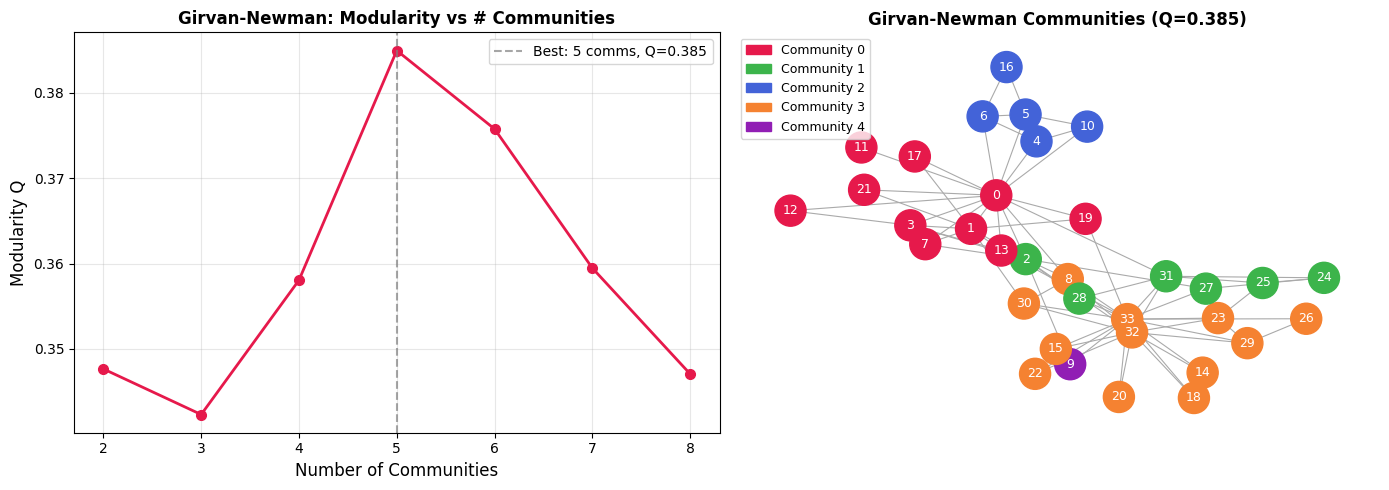

In [5]:
print("=" * 50)
print("  ALGORITHM 1: GIRVAN-NEWMAN")
print("=" * 50)

# Generator yields partitions at each split step
gn_gen = nx_comm.girvan_newman(G)

# Collect partitions and their modularity as we split
gn_history = []
for communities in gn_gen:
    comm_list = list(communities)
    Q = nx_comm.modularity(G, comm_list)
    gn_history.append((Q, comm_list))
    if len(comm_list) >= 8:   # stop at 8 communities
        break

# Best partition = highest modularity
best_Q, best_communities = max(gn_history, key=lambda x: x[0])
print(f"  Tested {len(gn_history)} splits (up to 8 communities)")
print(f"  Best split: {len(best_communities)} communities at Q={best_Q:.4f}")
print()

gn_result = evaluate(G, best_communities, "Girvan-Newman", ground_truth)
results['Girvan-Newman'] = gn_result

# Plot modularity vs number of communities
qs  = [x[0] for x in gn_history]
ncs = [len(x[1]) for x in gn_history]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Modularity curve
axes[0].plot(ncs, qs, 'o-', color='#e6194b', linewidth=2, markersize=7)
axes[0].axvline(x=len(best_communities), color='gray', linestyle='--', alpha=0.7,
                label=f'Best: {len(best_communities)} comms, Q={best_Q:.3f}')
axes[0].set_xlabel('Number of Communities', fontsize=12)
axes[0].set_ylabel('Modularity Q', fontsize=12)
axes[0].set_title('Girvan-Newman: Modularity vs # Communities', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Right: Network coloured by best partition
nx.draw_networkx(G, pos=pos,
                 node_color=color_map(gn_result['partition'], G),
                 node_size=500, font_size=9, font_color='white',
                 edge_color='#aaaaaa', width=0.8, ax=axes[1])
axes[1].legend(handles=legend_patches(gn_result['partition']), fontsize=9, loc='upper left')
axes[1].set_title(f"Girvan-Newman Communities (Q={best_Q:.3f})", fontsize=12, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.savefig('girvan_newman.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Algorithm 2: Greedy Modularity (Clauset-Newman-Moore)

### How it works
```
1. Start: every node = its own community
2. Try merging every pair of connected communities
3. Merge the pair that INCREASES modularity the most (ΔQ)
4. Repeat until no merge improves modularity
5. Return partition with highest Q ever seen
```

**Intuition:** Greedy bottom-up merging — always take the best local step.


  ALGORITHM 2: GREEDY MODULARITY (CNM)
  Algorithm             : Greedy Modularity
  Communities found     : 3
  Modularity Q          : 0.4110
  NMI (vs ground truth) : 0.5646

  Communities found:
    Community 0: [8, 14, 15, 18, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33]
    Community 1: [1, 2, 3, 7, 9, 12, 13, 17, 21]
    Community 2: [0, 4, 5, 6, 10, 11, 16, 19]


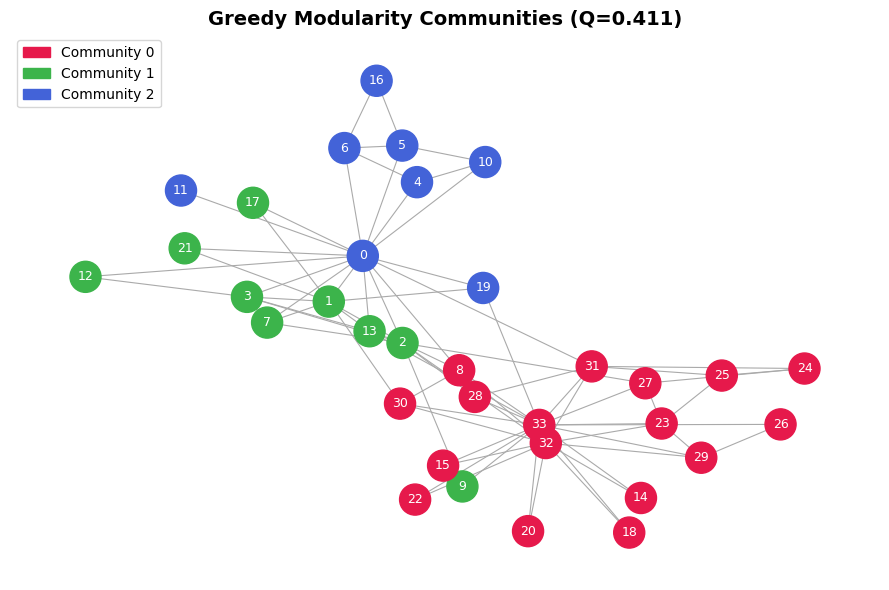

In [6]:
print("=" * 50)
print("  ALGORITHM 2: GREEDY MODULARITY (CNM)")
print("=" * 50)

gm_communities = list(nx_comm.greedy_modularity_communities(G))
gm_result = evaluate(G, gm_communities, "Greedy Modularity", ground_truth)
results['Greedy Modularity'] = gm_result

print("  Communities found:")
for i, comm in enumerate(sorted(gm_communities, key=len, reverse=True)):
    print(f"    Community {i}: {sorted(comm)}")

fig, ax = plt.subplots(figsize=(9, 6))
nx.draw_networkx(G, pos=pos,
                 node_color=color_map(gm_result['partition'], G),
                 node_size=500, font_size=9, font_color='white',
                 edge_color='#aaaaaa', width=0.8, ax=ax)
ax.legend(handles=legend_patches(gm_result['partition']), fontsize=10, loc='upper left')
ax.set_title(f"Greedy Modularity Communities (Q={gm_result['Q']:.3f})", fontsize=14, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig('greedy_modularity.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Algorithm 3: Louvain (Most Important ⭐)

### How it works — Two Phases Repeated

```
┌─────────────────────────────────────────────────────────┐
│  PHASE 1 — Modularity Optimization                      │
│                                                         │
│  For each node i:                                       │
│    Try moving i into each neighbour's community         │
│    If ΔQ > 0 → MOVE                                    │
│    Repeat until no node wants to move                   │
│                                                         │
├─────────────────────────────────────────────────────────┤
│  PHASE 2 — Community Aggregation                        │
│                                                         │
│  Each community → ONE supernode                         │
│  Internal links → self-loop (weight)                    │
│  Inter-community links → weighted edges                 │
│  Build compressed graph                                 │
└─────────────────────────────────────────────────────────┘
              ↕  REPEAT on compressed graph
```

**Why it's fast:** O(L) — linear in number of edges. Works on million-node networks.


  ALGORITHM 3: LOUVAIN
  Algorithm             : Louvain
  Communities found     : 4
  Modularity Q          : 0.4266
  NMI (vs ground truth) : 0.5942

  Communities found:
    Community 0: [8, 9, 14, 15, 18, 20, 22, 23, 26, 27, 29, 30, 32, 33]
    Community 1: [0, 4, 5, 6, 10, 11, 16, 17, 19, 21]
    Community 2: [1, 2, 3, 7, 12, 13]
    Community 3: [24, 25, 28, 31]


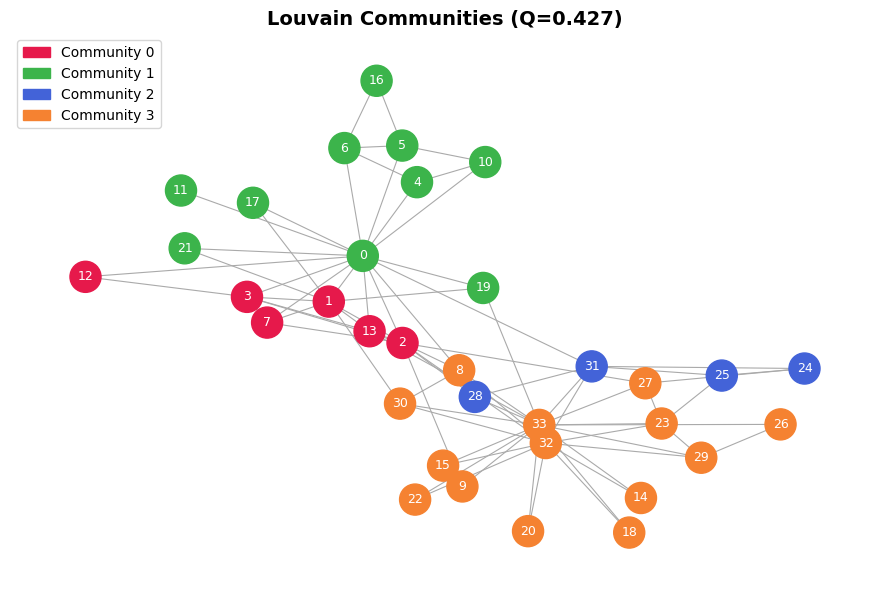

In [7]:
print("=" * 50)
print("  ALGORITHM 3: LOUVAIN")
print("=" * 50)

# ── Method A: NetworkX built-in Louvain
louvain_comms_nx = nx_comm.louvain_communities(G, seed=42)
louvain_result = evaluate(G, louvain_comms_nx, "Louvain", ground_truth)
results['Louvain'] = louvain_result

print("  Communities found:")
for i, comm in enumerate(sorted(louvain_comms_nx, key=len, reverse=True)):
    print(f"    Community {i}: {sorted(comm)}")

fig, ax = plt.subplots(figsize=(9, 6))
nx.draw_networkx(G, pos=pos,
                 node_color=color_map(louvain_result['partition'], G),
                 node_size=500, font_size=9, font_color='white',
                 edge_color='#aaaaaa', width=0.8, ax=ax)
ax.legend(handles=legend_patches(louvain_result['partition']), fontsize=10, loc='upper left')
ax.set_title(f"Louvain Communities (Q={louvain_result['Q']:.3f})", fontsize=14, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig('louvain.png', dpi=150, bbox_inches='tight')
plt.show()


### Louvain Deep Dive — Phase-by-Phase Visualisation

Louvain phase-by-phase progression:
----------------------------------------
  Phase 1: 5 communities | Q = 0.4016
    Community 0: size=14, nodes=[8, 9, 14, 15, 18, 20, 22, 23, 26, 27, 29, 30, 32, 33]
    Community 1: size=7, nodes=[0, 4, 10, 11, 17, 19, 21]
    Community 2: size=6, nodes=[1, 2, 3, 7, 12, 13]
    Community 3: size=4, nodes=[24, 25, 28, 31]
    Community 4: size=3, nodes=[5, 6, 16]

  Phase 2: 4 communities | Q = 0.4266
    Community 0: size=14, nodes=[8, 9, 14, 15, 18, 20, 22, 23, 26, 27, 29, 30, 32, 33]
    Community 1: size=10, nodes=[0, 4, 5, 6, 10, 11, 16, 17, 19, 21]
    Community 2: size=6, nodes=[1, 2, 3, 7, 12, 13]
    Community 3: size=4, nodes=[24, 25, 28, 31]



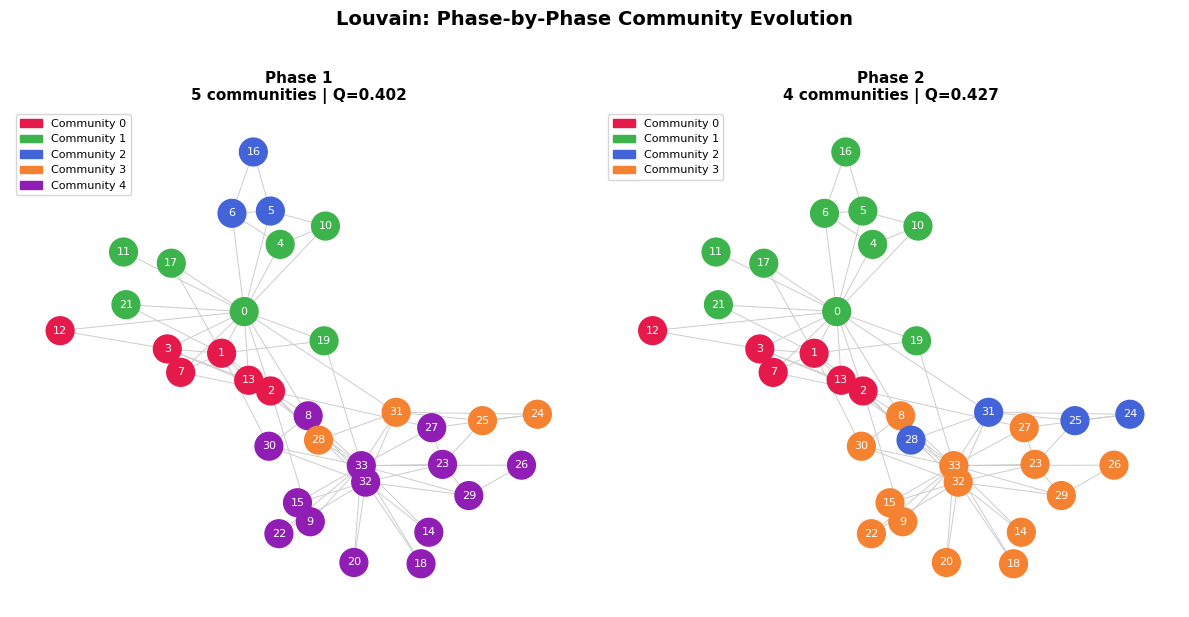

In [8]:
# ── Watch the phases using louvain_partitions (yields partition at each level)
print("Louvain phase-by-phase progression:")
print("-" * 40)

partitions_over_time = list(nx_comm.louvain_partitions(G, seed=42))
n_phases = len(partitions_over_time)

fig, axes = plt.subplots(1, n_phases, figsize=(6 * n_phases, 6))
if n_phases == 1:
    axes = [axes]

for phase_idx, phase_partition in enumerate(partitions_over_time):
    phase_list = list(phase_partition)
    Q = nx_comm.modularity(G, phase_list)
    part_dict = {n: cid for cid, comm in enumerate(phase_list) for n in comm}

    print(f"  Phase {phase_idx + 1}: {len(phase_list)} communities | Q = {Q:.4f}")
    for cid, comm in enumerate(sorted(phase_list, key=len, reverse=True)):
        print(f"    Community {cid}: size={len(comm)}, nodes={sorted(comm)}")
    print()

    ax = axes[phase_idx]
    nx.draw_networkx(G, pos=pos,
                     node_color=color_map(part_dict, G),
                     node_size=400, font_size=8, font_color='white',
                     edge_color='#cccccc', width=0.7, ax=ax)
    ax.legend(handles=legend_patches(part_dict), fontsize=8, loc='upper left')
    ax.set_title(f"Phase {phase_idx + 1}\n{len(phase_list)} communities | Q={Q:.3f}",
                 fontsize=11, fontweight='bold')
    ax.axis('off')

plt.suptitle("Louvain: Phase-by-Phase Community Evolution", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('louvain_phases.png', dpi=150, bbox_inches='tight')
plt.show()


### Louvain — Supernode Compression (Phase 2 Visualised)

Compressed graph (supernodes) after Phase 1:
  Supernodes : 5
  Super-edges: 7

  Supernode 0: 6 members, 10 internal links
    Members: [1, 2, 3, 7, 12, 13]
  Supernode 1: 7 members, 7 internal links
    Members: [0, 4, 10, 11, 17, 19, 21]
  Supernode 2: 3 members, 3 internal links
    Members: [5, 6, 16]
  Supernode 3: 4 members, 4 internal links
    Members: [24, 25, 28, 31]
  Supernode 4: 14 members, 26 internal links
    Members: [8, 9, 14, 15, 18, 20, 22, 23, 26, 27, 29, 30, 32, 33]

  Edges between supernodes:
    0 ── 1  (weight = 9)
    0 ── 4  (weight = 6)
    0 ── 3  (weight = 1)
    1 ── 2  (weight = 4)
    1 ── 4  (weight = 2)
    1 ── 3  (weight = 1)
    3 ── 4  (weight = 5)


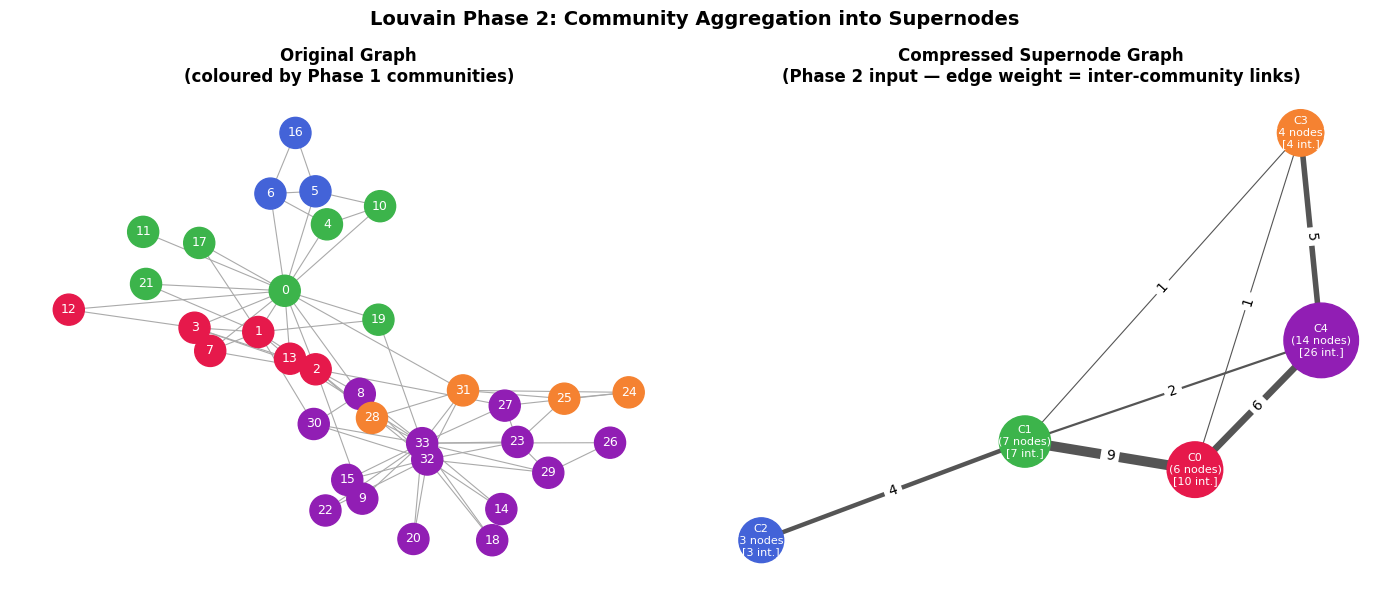

In [9]:
# Manually show the compressed graph after Phase 1
phase1_partition = list(partitions_over_time[0])
part1_dict = {n: cid for cid, comm in enumerate(phase1_partition) for n in comm}

# Build compressed graph (supernodes)
compressed = nx.Graph()
n_comms = len(phase1_partition)
compressed.add_nodes_from(range(n_comms))

# Internal edges → self-loops (stored as node attribute for display)
internal_weights = defaultdict(int)
for u, v in G.edges():
    cu, cv = part1_dict[u], part1_dict[v]
    if cu == cv:
        internal_weights[cu] += 1
    else:
        if compressed.has_edge(cu, cv):
            compressed[cu][cv]['weight'] += 1
        else:
            compressed.add_edge(cu, cv, weight=1)

print("Compressed graph (supernodes) after Phase 1:")
print(f"  Supernodes : {compressed.number_of_nodes()}")
print(f"  Super-edges: {compressed.number_of_edges()}")
print()
for node in compressed.nodes():
    members = sorted(phase1_partition[node])
    self_w  = internal_weights[node]
    print(f"  Supernode {node}: {len(members)} members, {self_w} internal links")
    print(f"    Members: {members}")
print()
print("  Edges between supernodes:")
for u, v, d in compressed.edges(data=True):
    print(f"    {u} ── {v}  (weight = {d['weight']})")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: original with Phase 1 communities highlighted
nx.draw_networkx(G, pos=pos,
                 node_color=color_map(part1_dict, G),
                 node_size=500, font_size=9, font_color='white',
                 edge_color='#aaaaaa', width=0.8, ax=axes[0])
axes[0].set_title("Original Graph\n(coloured by Phase 1 communities)", fontsize=12, fontweight='bold')
axes[0].axis('off')

# Right: compressed supernode graph
comp_pos = nx.spring_layout(compressed, seed=0)
node_sizes = [internal_weights[n] * 80 + 800 for n in compressed.nodes()]
edge_labels = nx.get_edge_attributes(compressed, 'weight')
node_labels_comp = {n: f"C{n}\n({len(phase1_partition[n])} nodes)\n[{internal_weights[n]} int.]"
                    for n in compressed.nodes()}
node_colors_comp = [PALETTE[n % len(PALETTE)] for n in compressed.nodes()]

nx.draw_networkx(compressed, pos=comp_pos,
                 node_color=node_colors_comp,
                 node_size=node_sizes, labels=node_labels_comp,
                 font_size=8, font_color='white',
                 width=[compressed[u][v]['weight'] * 0.8 for u,v in compressed.edges()],
                 edge_color='#555555', ax=axes[1])
nx.draw_networkx_edge_labels(compressed, comp_pos, edge_labels=edge_labels,
                              font_size=10, ax=axes[1])
axes[1].set_title("Compressed Supernode Graph\n(Phase 2 input — edge weight = inter-community links)",
                  fontsize=12, fontweight='bold')
axes[1].axis('off')

plt.suptitle("Louvain Phase 2: Community Aggregation into Supernodes",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('louvain_supernodes.png', dpi=150, bbox_inches='tight')
plt.show()


### Louvain — ΔQ Computation Explained

How does the algorithm decide whether to move a node? It calculates **ΔQ** — the change in modularity if we move node `i` from its current community to a neighbour's community.


In [10]:
def delta_Q(G, node, current_comm, target_comm, partition, L):
    """
    Compute change in modularity if 'node' moves from
    current_comm to target_comm.
    Simplified version for educational purposes.
    """
    ki = G.degree(node)          # degree of node i

    # Links from node to current community (excluding itself)
    k_i_in_current = sum(1 for nb in G.neighbors(node)
                         if partition[nb] == current_comm and nb != node)
    # Links from node to target community
    k_i_in_target  = sum(1 for nb in G.neighbors(node)
                         if partition[nb] == target_comm)

    # Total degree of current and target communities (excluding node)
    sigma_current = sum(G.degree(n) for n, c in partition.items()
                        if c == current_comm and n != node)
    sigma_target  = sum(G.degree(n) for n, c in partition.items()
                        if c == target_comm)

    # ΔQ formula
    dQ = (2*(k_i_in_target - k_i_in_current) / (2*L)
          - ki * (sigma_target - sigma_current) / (2*L**2))
    return dQ

# Demo: inspect ΔQ for node 0 (the instructor)
L = G.number_of_edges()
part_copy = dict(part1_dict)  # use Phase 1 partition

node = 0
current = part_copy[node]
print(f"Node {node} (Instructor) is currently in Community {current}")
print(f"Checking ΔQ for moving node {node} to each neighbour's community:")
print()

seen = set()
for nb in G.neighbors(node):
    target = part_copy[nb]
    if target != current and target not in seen:
        seen.add(target)
        dq = delta_Q(G, node, current, target, part_copy, L)
        arrow = "← MOVE" if dq > 0 else "← stay"
        print(f"  Current C{current} → Target C{target}: ΔQ = {dq:+.5f}  {arrow}")


Node 0 (Instructor) is currently in Community 1
Checking ΔQ for moving node 0 to each neighbour's community:

  Current C1 → Target C0: ΔQ = -0.02893  ← stay
  Current C1 → Target C2: ΔQ = -0.04602  ← stay
  Current C1 → Target C4: ΔQ = -0.13116  ← stay
  Current C1 → Target C3: ΔQ = -0.06542  ← stay


---
## Algorithm 4: Label Propagation

### How it works
```
1. Assign each node a UNIQUE label (community ID)
2. For each node (random order):
   Look at all neighbours
   Adopt the label that appears MOST among neighbours
3. Repeat until labels stop changing
4. Nodes with same label = same community
```

**Intuition:** Labels "flow" through the network and settle into dense regions.


  ALGORITHM 4: LABEL PROPAGATION
  Algorithm             : Label Propagation
  Communities found     : 3
  Modularity Q          : 0.3095
  NMI (vs ground truth) : 0.3636

  Communities found:
    Community 0: [2, 8, 9, 14, 15, 18, 20, 22, 23, 26, 27, 28, 29, 30, 32, 33]
    Community 1: [0, 1, 3, 4, 7, 10, 11, 12, 13, 17, 19, 21, 24, 25, 31]
    Community 2: [5, 6, 16]


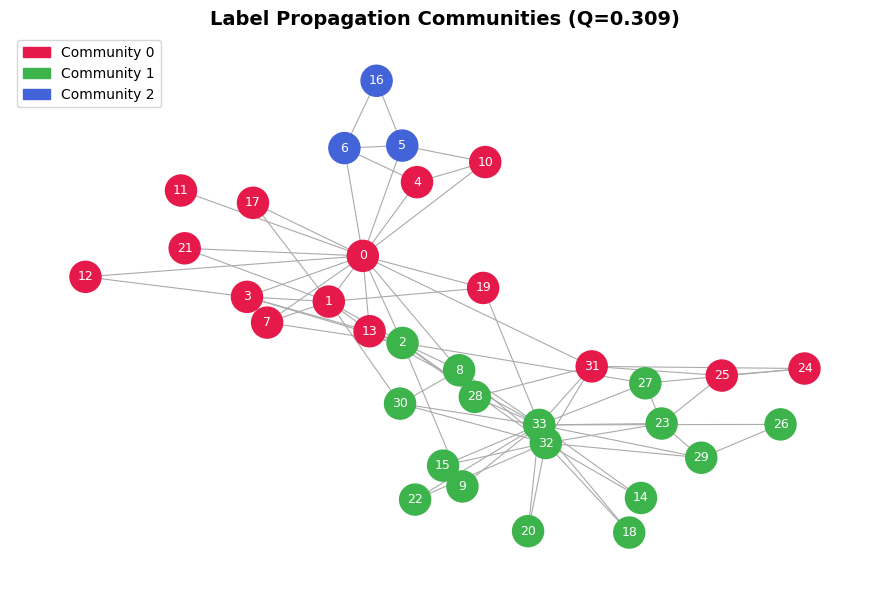

In [11]:
print("=" * 50)
print("  ALGORITHM 4: LABEL PROPAGATION")
print("=" * 50)

lp_communities = list(nx_comm.label_propagation_communities(G))
lp_result = evaluate(G, lp_communities, "Label Propagation", ground_truth)
results['Label Propagation'] = lp_result

print("  Communities found:")
for i, comm in enumerate(sorted(lp_communities, key=len, reverse=True)):
    print(f"    Community {i}: {sorted(comm)}")

fig, ax = plt.subplots(figsize=(9, 6))
nx.draw_networkx(G, pos=pos,
                 node_color=color_map(lp_result['partition'], G),
                 node_size=500, font_size=9, font_color='white',
                 edge_color='#aaaaaa', width=0.8, ax=ax)
ax.legend(handles=legend_patches(lp_result['partition']), fontsize=10, loc='upper left')
ax.set_title(f"Label Propagation Communities (Q={lp_result['Q']:.3f})", fontsize=14, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig('label_propagation.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Algorithm 5: K-Clique Percolation

### How it works
```
1. Find all cliques of size k (complete subgraphs)
2. Two k-cliques are "adjacent" if they share k-1 nodes
3. Chain of adjacent k-cliques = ONE community
4. Nodes not in any k-clique are ignored
```

**Special property:** Communities can **OVERLAP** — a node can belong to multiple communities!

```
k=3 means: groups of 3 nodes where all are connected (triangles)
```


  ALGORITHM 5: K-CLIQUE PERCOLATION
  k=3: 3 overlapping communities (+ 1 noise) | Q=0.1413
    Community 0: [0, 1, 2, 3, 7, 8, 12, 13, 14, 15, 17, 18, 19, 20, 21, 22, 23, 26, 27, 28, 29, 30, 31, 32, 33]
    Community 1: [0, 4, 5, 6, 10, 16]
    Community 2: [24, 25, 31]
  Algorithm             : K-Clique (k=3)
  Communities found     : 4
  Modularity Q          : 0.1413
  NMI (vs ground truth) : 0.1929


  k=4: 3 overlapping communities (+ 1 noise) | Q=0.1787
    Community 0: [0, 1, 2, 3, 7, 13]
    Community 1: [8, 30, 32, 33]
    Community 2: [23, 29, 32, 33]

  k=5: 1 overlapping communities (+ 1 noise) | Q=0.2251
    Community 0: [0, 1, 2, 3, 7, 13]



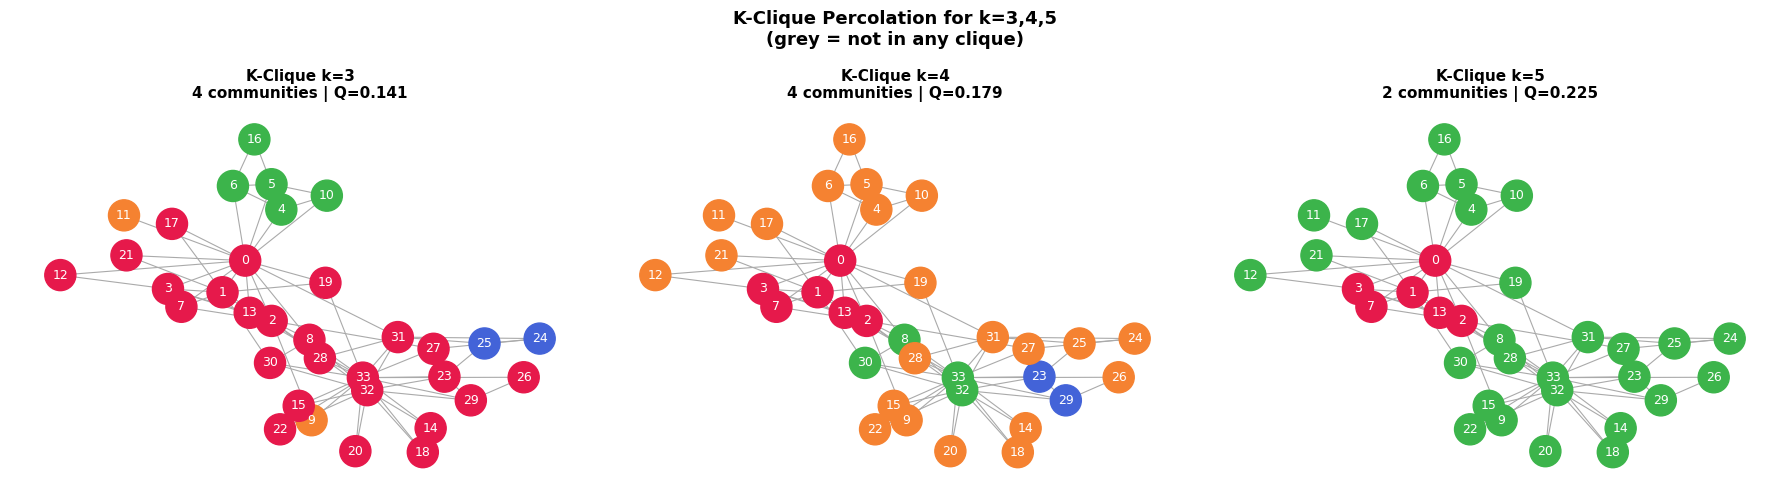

In [12]:
print("=" * 50)
print("  ALGORITHM 5: K-CLIQUE PERCOLATION")
print("=" * 50)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, k in enumerate([3, 4, 5]):
    kc_comms_raw = list(nx_comm.k_clique_communities(G, k))
    if not kc_comms_raw:
        print(f"  k={k}: No communities found (no {k}-cliques exist)")
        axes[idx].text(0.5, 0.5, f'k={k}: No {k}-cliques found',
                       ha='center', va='center', fontsize=12,
                       transform=axes[idx].transAxes)
        axes[idx].axis('off')
        continue

    # K-clique produces OVERLAPPING communities.
    # For modularity we need a proper partition → assign each node to its
    # largest community; assign uncovered nodes to a catch-all community.
    from collections import defaultdict
    node_to_comms = defaultdict(list)
    for cid, comm in enumerate(kc_comms_raw):
        for n in comm:
            node_to_comms[n].append(cid)

    part = {n: max(node_to_comms[n], key=lambda c: len(kc_comms_raw[c]))
            for n in G.nodes() if n in node_to_comms}
    # Nodes not covered by any clique → separate "noise" community
    noise_id = len(kc_comms_raw)
    for n in G.nodes():
        if n not in part:
            part[n] = noise_id

    # Build non-overlapping community list for modularity
    comm_sets = defaultdict(set)
    for n, cid in part.items():
        comm_sets[cid].add(n)
    kc_comms = [frozenset(s) for s in comm_sets.values()]

    Q = nx_comm.modularity(G, kc_comms)
    n_display = len(kc_comms_raw)   # show original overlapping count
    print(f"  k={k}: {n_display} overlapping communities (+ {len(comm_sets)-n_display} noise) | Q={Q:.4f}")
    for cid, comm in enumerate(sorted(kc_comms_raw, key=len, reverse=True)):
        print(f"    Community {cid}: {sorted(comm)}")

    if idx == 0:
        kc_result = evaluate(G, kc_comms, f"K-Clique (k={k})", ground_truth)
        results['K-Clique'] = kc_result

    node_colors = []
    for n in G.nodes():
        node_colors.append(PALETTE[part[n] % len(PALETTE)] if n in part else '#cccccc')

    nx.draw_networkx(G, pos=pos, node_color=node_colors,
                     node_size=500, font_size=9, font_color='white',
                     edge_color='#aaaaaa', width=0.8, ax=axes[idx])
    axes[idx].set_title(f"K-Clique k={k}\n{len(kc_comms)} communities | Q={Q:.3f}",
                        fontsize=11, fontweight='bold')
    axes[idx].axis('off')
    print()

plt.suptitle("K-Clique Percolation for k=3,4,5\n(grey = not in any clique)",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('kclique.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Algorithm 6: Spectral Clustering

### How it works
```
1. Build the Graph Laplacian matrix  L = D - A
   (D = degree matrix, A = adjacency matrix)
2. Compute eigenvectors of L
3. Use the SECOND smallest eigenvector (Fiedler vector)
   to split the graph
4. Nodes with +ve Fiedler value → Community 1
   Nodes with -ve Fiedler value → Community 2
```

**Intuition:** The Fiedler vector reveals the "natural cut" in the graph.


  ALGORITHM 6: SPECTRAL CLUSTERING
  Fiedler eigenvalue: 1.1871
  Fiedler vector (first 10): [ 0.123  0.058  0.014  0.074  0.267  0.299  0.297  0.064 -0.053 -0.129]

  Algorithm             : Spectral Clustering
  Communities found     : 2
  Modularity Q          : 0.4036
  NMI (vs ground truth) : 0.8372

  Community 0: [8, 9, 14, 15, 18, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33]
  Community 1: [0, 1, 2, 3, 4, 5, 6, 7, 10, 11, 12, 13, 16, 17, 19, 21]


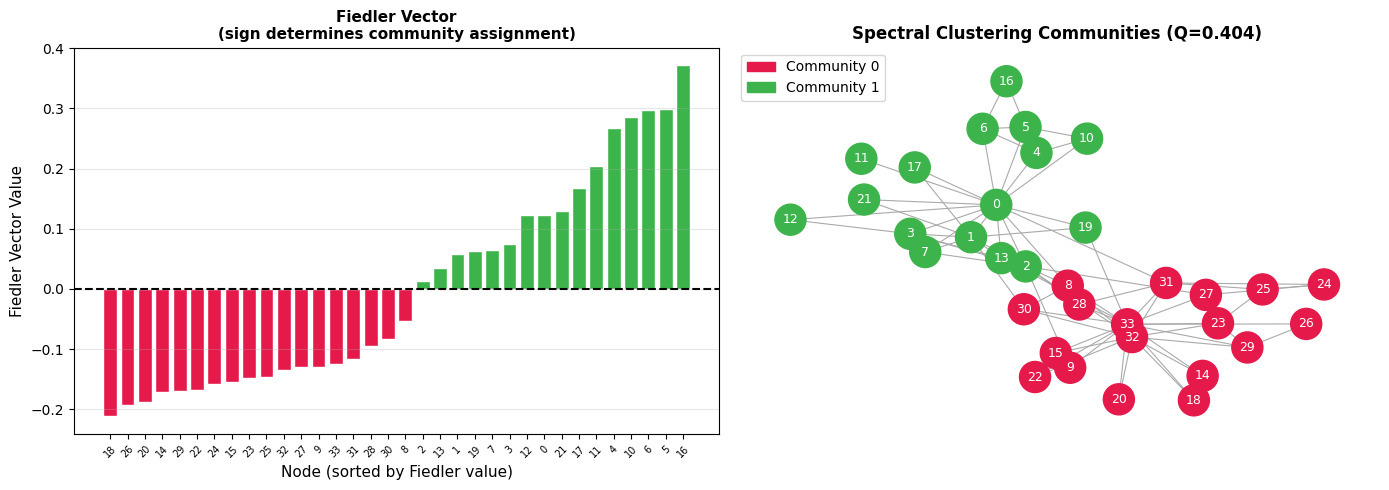

In [13]:
print("=" * 50)
print("  ALGORITHM 6: SPECTRAL CLUSTERING")
print("=" * 50)

# Compute Laplacian and its eigendecomposition
L_matrix = nx.laplacian_matrix(G).toarray().astype(float)
eigenvalues, eigenvectors = np.linalg.eigh(L_matrix)

# Fiedler vector = eigenvector corresponding to 2nd smallest eigenvalue
fiedler_idx    = 1   # index 0 is always 0 (trivial)
fiedler_vector = eigenvectors[:, fiedler_idx]

print(f"  Fiedler eigenvalue: {eigenvalues[fiedler_idx]:.4f}")
print(f"  Fiedler vector (first 10): {fiedler_vector[:10].round(3)}")
print()

# Partition by sign of Fiedler vector
nodes = list(G.nodes())
spectral_partition = {nodes[i]: (0 if fiedler_vector[i] <= 0 else 1)
                      for i in range(len(nodes))}

comm0 = frozenset(n for n, c in spectral_partition.items() if c == 0)
comm1 = frozenset(n for n, c in spectral_partition.items() if c == 1)
spectral_comms = [comm0, comm1]
spectral_result = evaluate(G, spectral_comms, "Spectral Clustering", ground_truth)
results['Spectral'] = spectral_result

print(f"  Community 0: {sorted(comm0)}")
print(f"  Community 1: {sorted(comm1)}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Fiedler vector values per node
sorted_nodes = sorted(nodes, key=lambda n: fiedler_vector[nodes.index(n)])
fiedler_vals = [fiedler_vector[nodes.index(n)] for n in sorted_nodes]
colors_bar   = [PALETTE[0] if v <= 0 else PALETTE[1] for v in fiedler_vals]

axes[0].bar(range(len(sorted_nodes)), fiedler_vals, color=colors_bar, edgecolor='white')
axes[0].axhline(0, color='black', linewidth=1.5, linestyle='--')
axes[0].set_xticks(range(len(sorted_nodes)))
axes[0].set_xticklabels(sorted_nodes, fontsize=7, rotation=45)
axes[0].set_xlabel('Node (sorted by Fiedler value)', fontsize=11)
axes[0].set_ylabel('Fiedler Vector Value', fontsize=11)
axes[0].set_title('Fiedler Vector\n(sign determines community assignment)', fontsize=11, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Right: Network coloured by spectral communities
nx.draw_networkx(G, pos=pos,
                 node_color=color_map(spectral_partition, G),
                 node_size=500, font_size=9, font_color='white',
                 edge_color='#aaaaaa', width=0.8, ax=axes[1])
axes[1].legend(handles=legend_patches(spectral_partition), fontsize=10, loc='upper left')
axes[1].set_title(f"Spectral Clustering Communities (Q={spectral_result['Q']:.3f})",
                  fontsize=12, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.savefig('spectral.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Final Comparison — All Algorithms

Let's compare all algorithms side by side.


In [14]:
from sklearn.metrics import normalized_mutual_info_score

# Rebuild clean results table
print("=" * 65)
print(f"  {'Algorithm':<22} {'# Comms':>7} {'Modularity Q':>13} {'NMI':>8}")
print("=" * 65)
for name, r in results.items():
    print(f"  {name:<22} {r['n_comm']:>7} {r['Q']:>13.4f} {r['NMI']:>8.4f}")
print("=" * 65)
print()
best = max(results.items(), key=lambda x: x[1]['Q'])
print(f"  ★ Best Modularity : {best[0]} (Q={best[1]['Q']:.4f})")
best_nmi = max(results.items(), key=lambda x: x[1]['NMI'])
print(f"  ★ Best NMI        : {best_nmi[0]} (NMI={best_nmi[1]['NMI']:.4f})")


  Algorithm              # Comms  Modularity Q      NMI
  Girvan-Newman                5        0.3850   0.4851
  Greedy Modularity            3        0.4110   0.5646
  Louvain                      4        0.4266   0.5942
  Label Propagation            3        0.3095   0.3636
  K-Clique                     4        0.1413   0.1929
  Spectral                     2        0.4036   0.8372

  ★ Best Modularity : Louvain (Q=0.4266)
  ★ Best NMI        : Spectral (NMI=0.8372)


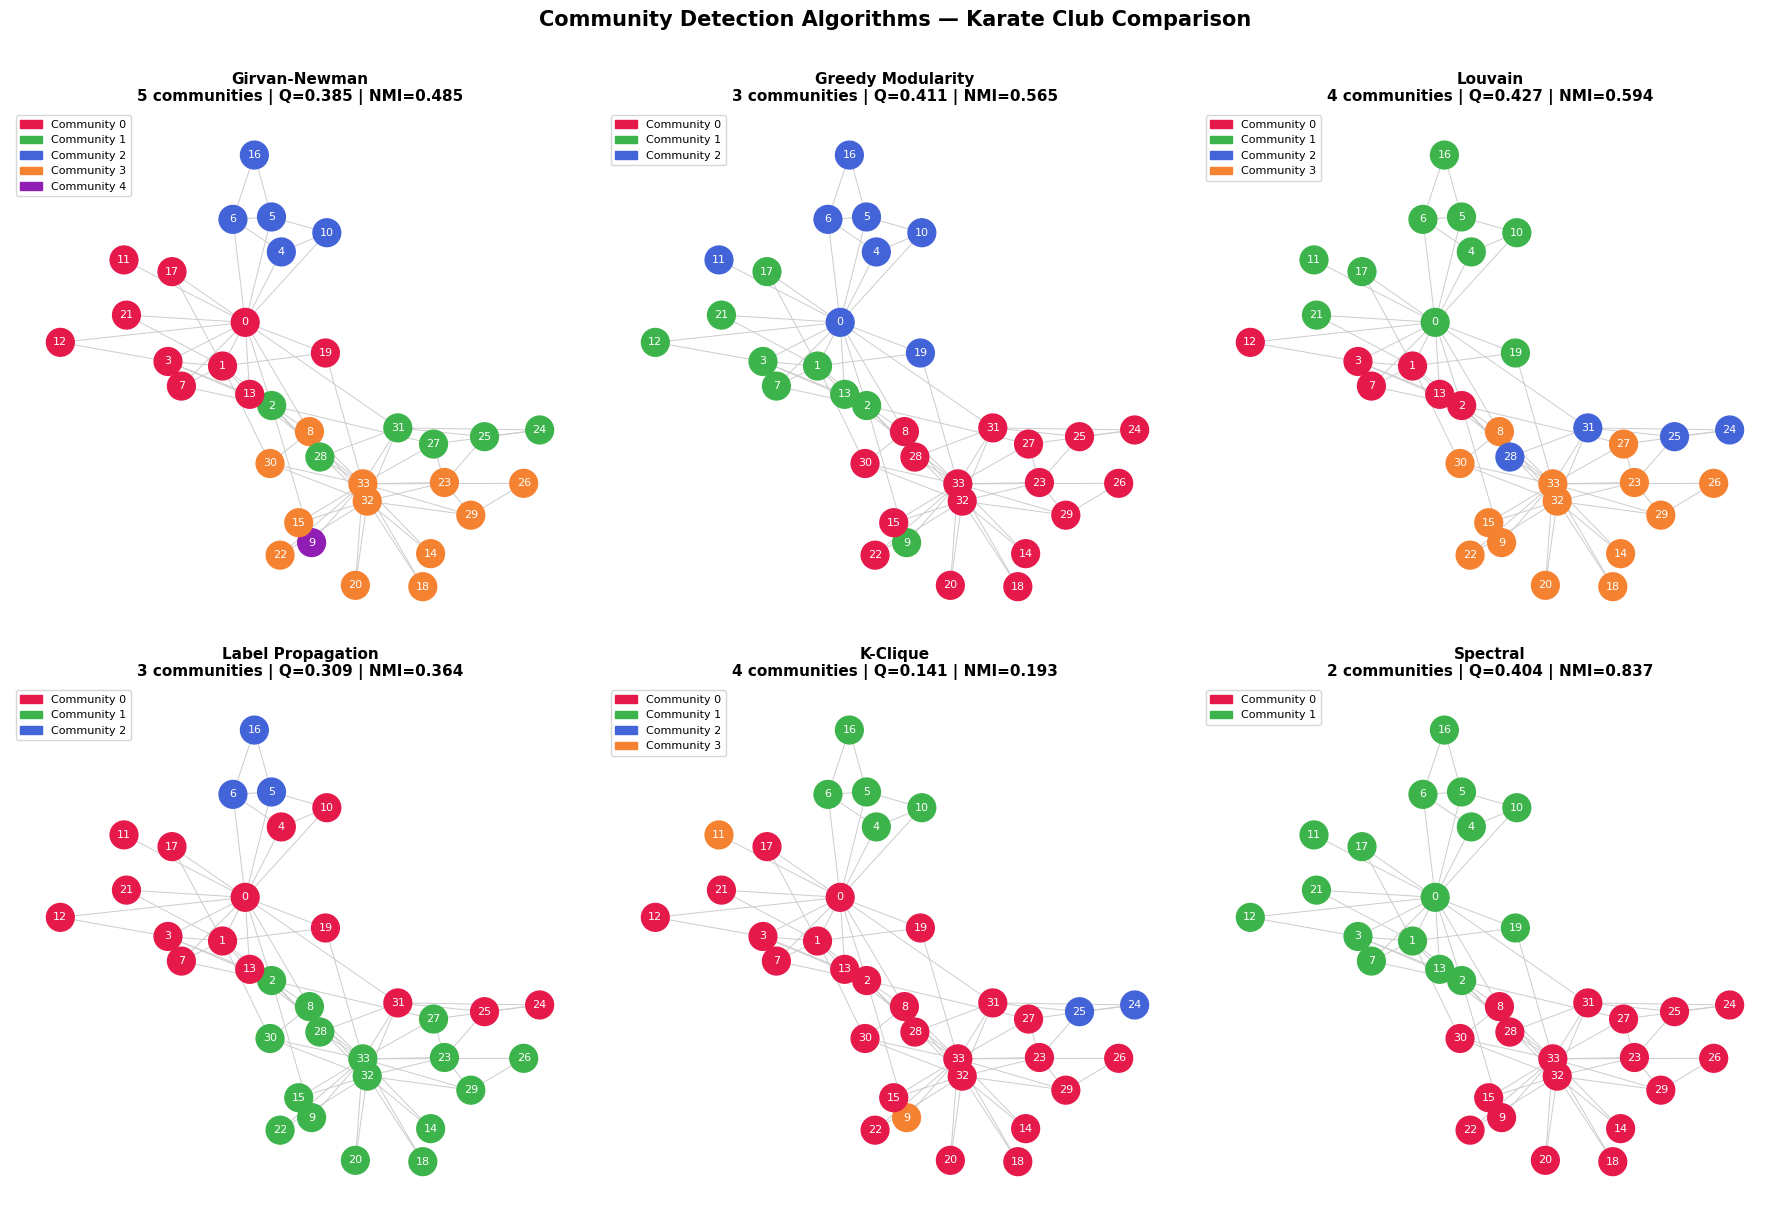

In [15]:
# ── All algorithms side by side
n_algs = len(results)
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, (name, r) in enumerate(results.items()):
    ax = axes[idx]
    nx.draw_networkx(G, pos=pos,
                     node_color=color_map(r['partition'], G),
                     node_size=400, font_size=8, font_color='white',
                     edge_color='#cccccc', width=0.7, ax=ax)
    ax.legend(handles=legend_patches(r['partition']), fontsize=8, loc='upper left')
    ax.set_title(f"{name}\n{r['n_comm']} communities | Q={r['Q']:.3f} | NMI={r['NMI']:.3f}",
                 fontsize=11, fontweight='bold')
    ax.axis('off')

plt.suptitle("Community Detection Algorithms — Karate Club Comparison",
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('all_algorithms_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


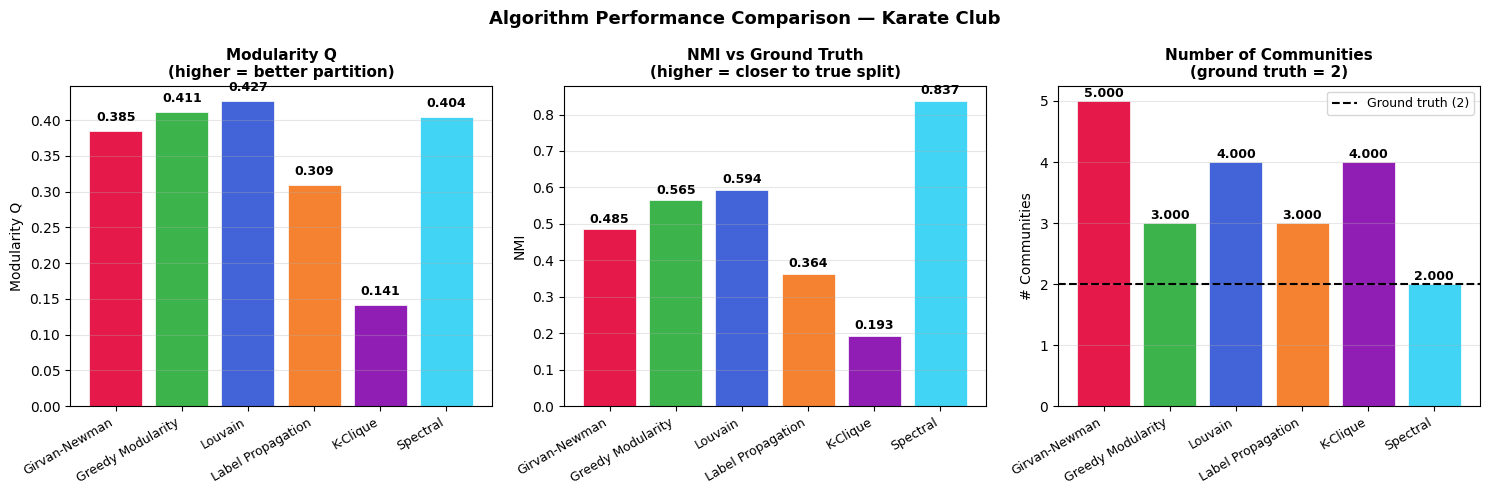

In [16]:
# ── Bar chart comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
names = list(results.keys())
Qs    = [results[n]['Q']      for n in names]
NMIs  = [results[n]['NMI']    for n in names]
ncs   = [results[n]['n_comm'] for n in names]

bar_colors = [PALETTE[i % len(PALETTE)] for i in range(len(names))]

for ax, vals, title, ylabel in zip(
        axes,
        [Qs, NMIs, ncs],
        ['Modularity Q\n(higher = better partition)',
         'NMI vs Ground Truth\n(higher = closer to true split)',
         'Number of Communities\n(ground truth = 2)'],
        ['Modularity Q', 'NMI', '# Communities']):
    bars = ax.bar(names, vals, color=bar_colors, edgecolor='white', linewidth=0.5)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_xticklabels(names, rotation=30, ha='right', fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    if ylabel == '# Communities':
        ax.axhline(2, color='black', linestyle='--', linewidth=1.5, label='Ground truth (2)')
        ax.legend(fontsize=9)

plt.suptitle("Algorithm Performance Comparison — Karate Club", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('comparison_bars.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Ground Truth vs Louvain — Node-by-Node Accuracy


  Louvain accuracy vs ground truth: 67.6%
  Correctly classified : 23 nodes → [0, 4, 5, 6, 9, 10, 11, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 26, 27, 29, 30, 32, 33]
  Misclassified        : 11 nodes → [1, 2, 3, 7, 8, 12, 13, 24, 25, 28, 31]


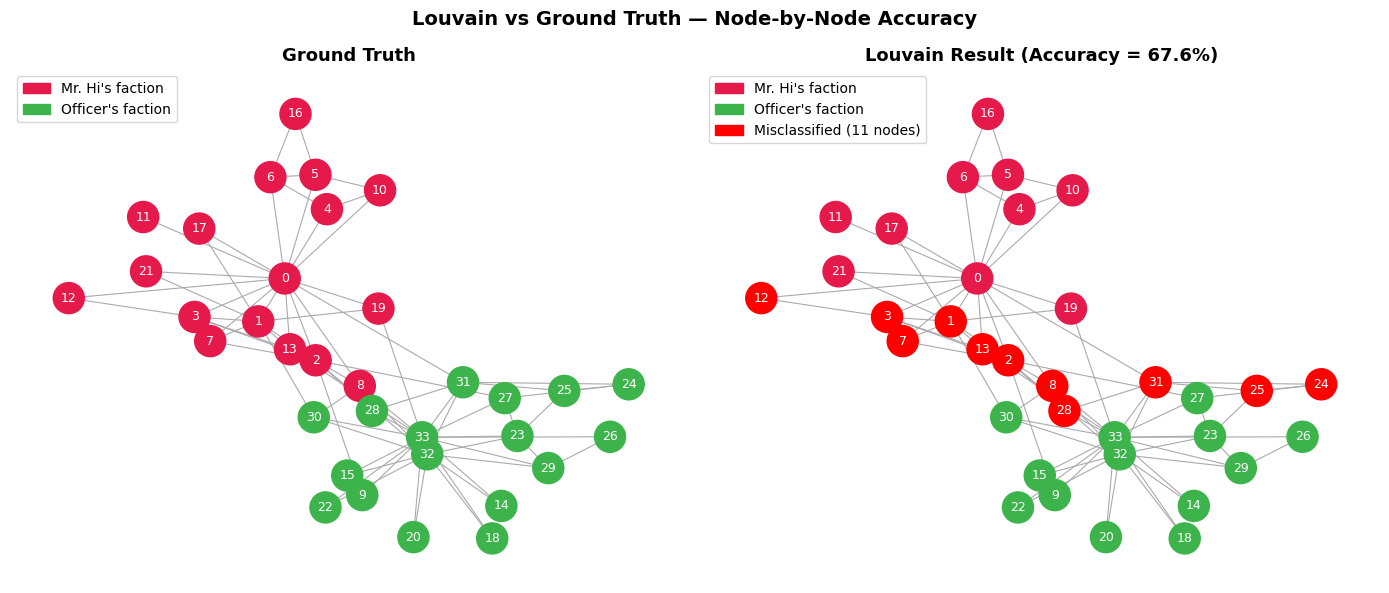

In [17]:
from sklearn.metrics import confusion_matrix
import itertools

louvain_part = louvain_result['partition']

# Align community labels (Louvain community IDs may not match GT 0/1)
def align_labels(gt, pred):
    """Try both label assignments and return the one with higher accuracy."""
    nodes = sorted(gt.keys())
    gt_arr   = np.array([gt[n]   for n in nodes])
    pred_arr = np.array([pred[n] for n in nodes])
    # Try identity and flip
    acc1 = np.mean(gt_arr == pred_arr)
    # Remap pred labels
    unique_pred = list(set(pred_arr))
    best_acc, best_map = 0, {}
    for perm in itertools.permutations(range(len(unique_pred))):
        mapping = {unique_pred[i]: perm[i] for i in range(len(unique_pred))}
        mapped  = np.array([mapping[p] for p in pred_arr])
        acc = np.mean(gt_arr == mapped)
        if acc > best_acc:
            best_acc = acc
            best_map = mapping
    return best_acc, best_map

acc, mapping = align_labels(ground_truth, louvain_part)
aligned_pred = {n: mapping.get(louvain_part[n], louvain_part[n]) for n in G.nodes()}

correct   = [n for n in G.nodes() if ground_truth[n] == aligned_pred[n]]
incorrect = [n for n in G.nodes() if ground_truth[n] != aligned_pred[n]]

print(f"  Louvain accuracy vs ground truth: {acc*100:.1f}%")
print(f"  Correctly classified : {len(correct)} nodes → {sorted(correct)}")
print(f"  Misclassified        : {len(incorrect)} nodes → {sorted(incorrect)}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Ground truth
nx.draw_networkx(G, pos=pos,
                 node_color=[PALETTE[ground_truth[n]] for n in G.nodes()],
                 node_size=500, font_size=9, font_color='white',
                 edge_color='#aaaaaa', width=0.8, ax=axes[0])
axes[0].legend(handles=[
    mpatches.Patch(color=PALETTE[0], label="Mr. Hi's faction"),
    mpatches.Patch(color=PALETTE[1], label="Officer's faction")
], fontsize=10, loc='upper left')
axes[0].set_title("Ground Truth", fontsize=13, fontweight='bold')
axes[0].axis('off')

# Louvain with misclassified highlighted
node_colors_check = []
for n in G.nodes():
    if n in incorrect:
        node_colors_check.append('#FF0000')   # bright red = wrong
    else:
        node_colors_check.append(PALETTE[ground_truth[n]])

nx.draw_networkx(G, pos=pos, node_color=node_colors_check,
                 node_size=500, font_size=9, font_color='white',
                 edge_color='#aaaaaa', width=0.8, ax=axes[1])
axes[1].legend(handles=[
    mpatches.Patch(color=PALETTE[0], label="Mr. Hi's faction"),
    mpatches.Patch(color=PALETTE[1], label="Officer's faction"),
    mpatches.Patch(color='#FF0000',  label=f"Misclassified ({len(incorrect)} nodes)")
], fontsize=10, loc='upper left')
axes[1].set_title(f"Louvain Result (Accuracy = {acc*100:.1f}%)",
                  fontsize=13, fontweight='bold')
axes[1].axis('off')

plt.suptitle("Louvain vs Ground Truth — Node-by-Node Accuracy",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('louvain_vs_ground_truth.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Summary & Key Takeaways

| Algorithm | Idea | Complexity | Communities | Best For |
|-----------|------|-----------|-------------|----------|
| **Girvan-Newman** | Remove bridge edges | O(L·n·m) | Variable | Small-medium graphs |
| **Greedy Modularity** | Merge → maximize Q | O(N log² N) | Few large | Medium graphs |
| **Louvain** ⭐ | Phase1+Phase2 iterative | **O(L)** | Few-many | **Very large graphs** |
| **Label Propagation** | Labels flow through network | O(N+L) | Variable | Fast approximate |
| **K-Clique** | Chain of overlapping cliques | Expensive | Overlapping | Overlapping communities |
| **Spectral** | Graph Laplacian eigenvectors | O(N³) | 2 (bisection) | Well-separated graphs |

### Why Louvain is the Most Popular
- **Fastest** — O(L) scales to billions of edges
- **Hierarchical** — finds communities at multiple scales
- **High quality** — consistently high modularity
- **Phase 2** is the key insight: compressing communities into supernodes allows finding larger structures efficiently
